:::{admonition} Do this exercise yourself!
:class: important

This notebook is an exercise for practicing using plenoptic. You should work through it on your own, either by clicking on one of the following buttons or opening up a new notebook on your own machine and following along.

Regardless of which you choose, you should keep this page open for reference, as the links to other pages in the documentation (and some images) are broken in the downloaded and binder notebooks.

If you would like to install everything required to run this notebooks on your local machine, run `pip install plenoptic[nb]`. See [](install-doc) and [](jupyter-doc) for more details.

Download the executed notebook: **{nb-download}`2_simple_eigendistortion.ipynb`**!

Run it in your browser: **{binder}`2_simple_eigendistortion.ipynb`**!

:::

# Minimal eigendistortion synthesis example

See [](eigendistortion-nb) page for more details about using the {class}`~plenoptic.Eigendistortion` object.

In [1]:
# needed for the plotting/animating:
import matplotlib.pyplot as plt
import torch

import plenoptic as po

plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]
# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The following code block:
- initializes an image and a model
- runs eigendistortion synthesis until convergence

In [2]:
img = po.data.einstein().to(DEVICE)
model = po.models.LuminanceGainControl(
    kernel_size=(31, 31), pad_mode="circular", pretrained=True, cache_filt=True
)
model.to(DEVICE)
po.remove_grad(model)
model.eval()
eig = po.Eigendistortion(img, model)
eig.synthesize(max_iter=1000)

Top k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Bottom k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Unlike metamers (and MAD Competition), eigendistortion doesn't use an iterative optimization procedure in order to synthesize its images. It uses the "power iteration method" to find the eigenvector and eigenvalue of the model's Fisher Information Matrix (see [original paper](https://www.cns.nyu.edu/pub/lcv/berardino17c-final.pdf) for details).

This means that, to ensure we have actually found the eigendistortions, we need to let the synthesis run until the synthesized images have stopped changing, i.e., until we hit the stop criterion in the synthesis above. Assuming that happens, then synthesis has succeeded.

We can then visualize our outputs:

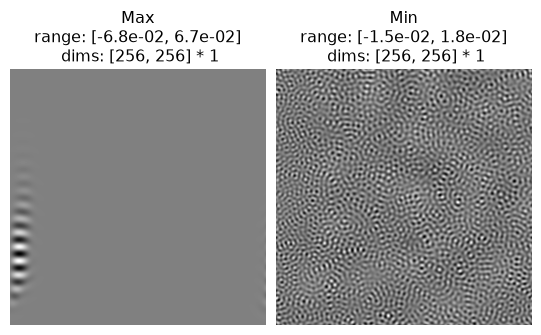

In [3]:
po.plot.imshow(eig.eigendistortions, title=["Max", "Min"]);

And we can add them to the reference image, to see what they look like (scaled up for visibility):

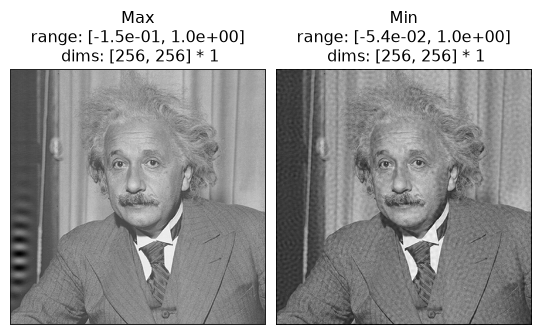

In [4]:
po.plot.imshow(eig.image + 5 * eig.eigendistortions, title=["Max", "Min"]);

## Different target image

Try using a different target image than the one of Einstein above and running eigendistortion synthesis until completion:

:::{admonition} Loading other images
:class: hint

Try one of the other {ref}`included images <images-api>` or use {func}`plenoptic.load_images` to load one from disk.

:::

In [ ]:
img = ...  # WRITE SOMETHING NEW HERE
img = img.to(DEVICE)
model = po.models.LuminanceGainControl(
    kernel_size=(31, 31), pad_mode="circular", pretrained=True, cache_filt=True
)
model.to(DEVICE)
po.remove_grad(model)
model.eval()
eig = po.Eigendistortion(img, model)
eig.synthesize(max_iter=1000)
po.plot.imshow([eig.eigendistortions, eig.image + 5 * eig.eigendistortions]);

## Other models

Try any of the above with a different model! Try one of the other {ref}`LGN-inspired models <models-api>`.

If you want a more complex model, see the [](4_torchvision) notebooks.